# Compare saved XGBoost and RPT predictions

## Goal

Compare both models on the **same 128 held-out synthetic invoices**. This notebook reads saved result files only; it never calls BTP or retrains a model. If a validated direct BTP run exists, it uses that. Otherwise it uses the supplied Playground table export and labels the source clearly.

The Playground CSV has no model metadata or probabilities; its attribution to RPT follows the supplied file's provenance. RPT ROC AUC cannot be calculated from class labels alone.

## 1. Load and validate XGBoost results

In [1]:
import hashlib
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display, Markdown
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

ROOT = next(path for path in (Path.cwd(), Path.cwd().parent) if (path / "data/synthetic_invoices/payment_behavior.csv").exists())
DATA = ROOT / "data/synthetic_invoices"
TARGETS = ("paid_late", "is_fraud")
CONTEXT_ROWS = 1024
PREDICTION_ROWS = 128
source = pd.read_csv(DATA / "payment_behavior.csv")
test = source.iloc[CONTEXT_ROWS:].reset_index(drop=True)
xgb = pd.read_csv(DATA / "xgboost_results.csv")
assert len(source) == 1152 and len(test) == len(xgb) == PREDICTION_ROWS
assert test.invoice_id.is_unique and xgb.invoice_id.is_unique
assert xgb.invoice_id.tolist() == test.invoice_id.tolist()
for target in TARGETS:
    assert xgb[f"actual_{target}"].tolist() == test[target].tolist()
    assert xgb[f"predicted_{target}"].isin([0, 1]).all()
    assert xgb[f"probability_{target}"].between(0, 1).all()
print(f"Validated XGBoost predictions for {len(test)} shared test invoices.")

Validated XGBoost predictions for 128 shared test invoices.


## 2. Select the saved RPT result

The BTP result takes priority only when its metadata identifies a direct deployment run and matches the current request. Without it, this notebook uses the supplied Playground export and says so in the tables and chart.

In [2]:
btp_path = DATA / "rpt16_results.csv"
metadata_path = DATA / "rpt16_run_metadata.json"
playground_path = DATA / "exports/rpt_playground_export.csv"
request_path = DATA / "rpt16_request.json"

if btp_path.exists():
    if not metadata_path.exists():
        raise ValueError("A BTP result exists without run metadata; verify its origin before comparing.")
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    if metadata["source"] != "btp_deployment":
        raise ValueError("The saved RPT result is not marked as a direct BTP deployment run.")
    if metadata["request_sha256"] != hashlib.sha256(request_path.read_bytes()).hexdigest():
        raise ValueError("The BTP result was produced from a different request payload.")
    if metadata["results_sha256"] != hashlib.sha256(btp_path.read_bytes()).hexdigest():
        raise ValueError("The BTP results file does not match its recorded checksum.")
    rpt = pd.read_csv(btp_path)
    rpt_source = f"{metadata.get('model_configured') or 'SAP-RPT deployment'} (BTP)"
    source_note = f"Direct BTP response recorded {metadata['run_at_utc']} (UTC); deployment configuration: {metadata.get('deployment_configuration_name') or 'unavailable'}."
else:
    exported = pd.read_csv(playground_path)
    assert len(exported) == len(source)
    assert exported.invoice_id.is_unique
    assert exported.invoice_id.tolist() == source.invoice_id.tolist()
    feature_columns = [column for column in source.columns if column not in TARGETS]
    pd.testing.assert_frame_equal(exported[feature_columns], source[feature_columns], check_dtype=False)
    for target in TARGETS:
        assert exported[target].iloc[:CONTEXT_ROWS].tolist() == source[target].iloc[:CONTEXT_ROWS].tolist()
        assert exported[target].iloc[CONTEXT_ROWS:].isin([0, 1]).all()
    rpt = pd.DataFrame({"invoice_id": test.invoice_id})
    for target in TARGETS:
        rpt[f"actual_{target}"] = test[target].to_numpy()
        rpt[f"predicted_{target}"] = exported[target].iloc[CONTEXT_ROWS:].to_numpy()
    rpt_source = "RPT Playground export"
    source_note = "No direct BTP result is saved; using the user-supplied Playground CSV, which has no model metadata."

assert len(rpt) == PREDICTION_ROWS and rpt.invoice_id.is_unique
assert rpt.invoice_id.tolist() == test.invoice_id.tolist()
for target in TARGETS:
    assert rpt[f"actual_{target}"].tolist() == test[target].tolist()
    assert rpt[f"predicted_{target}"].isin([0, 1]).all()
print(source_note)

Direct BTP response recorded 2026-10-03T19:42:23.341603+00:00 (UTC); deployment configuration: sap-rpt-1.6-large_autogenerated.


## 3. Calculate comparable metrics

Accuracy, precision, and recall use class labels from both models. XGBoost ROC AUC uses its saved probabilities. RPT ROC AUC stays blank because the exported confidence is not a verified probability of the positive class.

In [3]:
metric_rows = []
confusion_rows = []
for model_name, frame in [("XGBoost", xgb), (rpt_source, rpt)]:
    for target in TARGETS:
        actual = frame[f"actual_{target}"]
        predicted = frame[f"predicted_{target}"]
        tn, fp, fn, tp = confusion_matrix(actual, predicted, labels=[0, 1]).ravel()
        metric_rows.append({
            "Model": model_name, "Target": target, "Positive cases": int(actual.sum()),
            "Accuracy": accuracy_score(actual, predicted),
            "Precision": precision_score(actual, predicted, zero_division=0),
            "Recall": recall_score(actual, predicted, zero_division=0),
            "ROC AUC": roc_auc_score(actual, frame[f"probability_{target}"]) if model_name == "XGBoost" else float("nan"),
        })
        confusion_rows.append({"Model": model_name, "Target": target,
                               "True positives": tp, "False positives": fp,
                               "False negatives": fn, "True negatives": tn})
metrics = pd.DataFrame(metric_rows).set_index(["Model", "Target"])
display(metrics.round(3))
display(pd.DataFrame(confusion_rows).set_index(["Model", "Target"]))

Positive cases  Accuracy  Precision  \
Model                   Target                                           
XGBoost                 paid_late              51     0.656      0.561   
                        is_fraud                8     0.906      0.250   
sap-rpt-1.6-large (BTP) paid_late              51     0.719      0.642   
                        is_fraud                8     0.922      0.000   

                                   Recall  ROC AUC  
Model                   Target                      
XGBoost                 paid_late   0.627    0.724  
                        is_fraud    0.250    0.699  
sap-rpt-1.6-large (BTP) paid_late   0.667      NaN  
                        is_fraud    0.000      NaN

True positives  False positives  \
Model                   Target                                       
XGBoost                 paid_late              32               25   
                        is_fraud                2                6   
sap-rpt-1.6-large (BTP) paid_late              34               19   
                        is_fraud                0                2   

                                   False negatives  True negatives  
Model                   Target                                      
XGBoost                 paid_late               19              52  
                        is_fraud                 6             114  
sap-rpt-1.6-large (BTP) paid_late               17              58  
                        is_fraud                 8             118

## 4. Visualize the comparison

Each chart uses the same scale. There are 51 actual late-payment cases and 8 actual fraud cases among the 128 test invoices. For fraud, recall is essential because overall accuracy can hide missed positive cases.

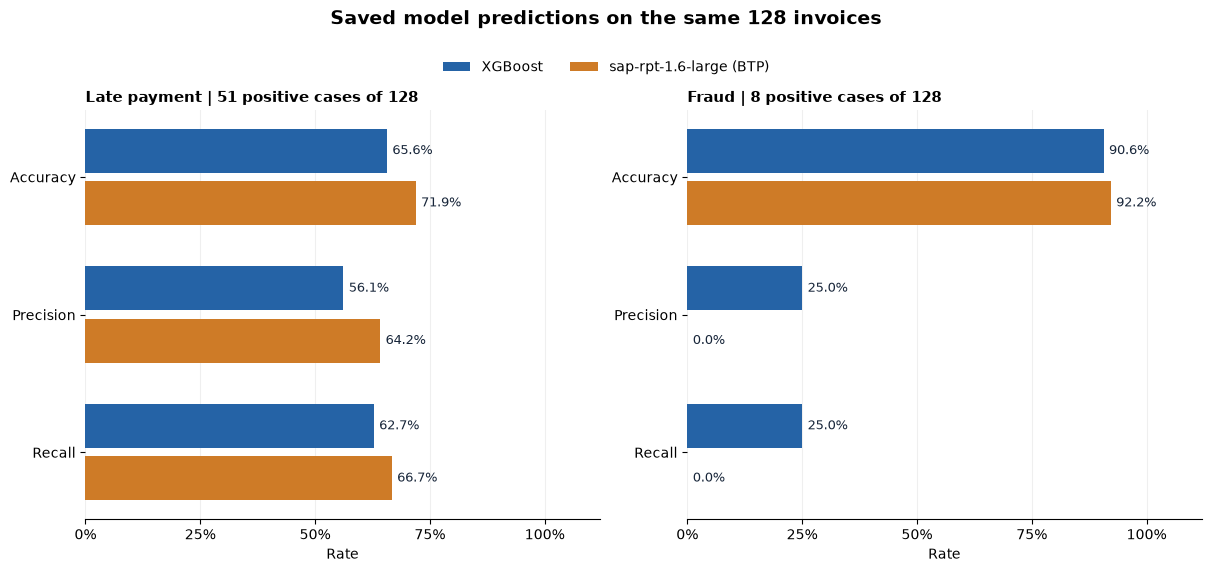

Saved chart: notebooks/saved_results_comparison.png


In [4]:
plot_metrics = ["Accuracy", "Precision", "Recall"]
model_colors = {"XGBoost": "#2563a6", rpt_source: "#ce7b27"}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, constrained_layout=True)
for ax, target, title in zip(axes, TARGETS, ["Late payment", "Fraud"]):
    for model_name, offset in [("XGBoost", -0.19), (rpt_source, 0.19)]:
        values = [metrics.loc[(model_name, target), metric] * 100 for metric in plot_metrics]
        bars = ax.barh([index + offset for index in range(3)], values,
                       height=0.32, color=model_colors[model_name])
        for bar, value in zip(bars, values):
            ax.text(max(value + 1.2, 1.2), bar.get_y() + bar.get_height() / 2,
                    f"{value:.1f}%", va="center", fontsize=9, color="#18263a")
    ax.set_yticks(range(3), plot_metrics)
    ax.invert_yaxis()
    ax.set_xlim(0, 112)
    ax.set_xticks([0, 25, 50, 75, 100], ["0%", "25%", "50%", "75%", "100%"])
    ax.set_xlabel("Rate")
    ax.set_title(f"{title} | {int(test[target].sum())} positive cases of 128", loc="left", fontsize=11, weight="bold")
    ax.xaxis.grid(True, alpha=0.2)
    ax.set_axisbelow(True)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
fig.legend(handles=[Patch(facecolor=model_colors[name], label=name) for name in model_colors],
           loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False)
fig.suptitle("Saved model predictions on the same 128 invoices", y=1.16,
             fontsize=14, weight="bold")
chart_path = ROOT / "notebooks/saved_results_comparison.png"
fig.savefig(chart_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved chart: {chart_path.relative_to(ROOT)}")

## Takeaways

Use the source label above to distinguish a direct BTP run from the supplied Playground export. Read fraud recall and its **8 actual positive cases** alongside accuracy. These are synthetic teaching data; a single fixed split does not establish production performance. The next cell summarizes the currently selected saved results.

In [5]:
late_xgb = metrics.loc[("XGBoost", "paid_late")]
late_rpt = metrics.loc[(rpt_source, "paid_late")]
fraud_xgb = metrics.loc[("XGBoost", "is_fraud")]
fraud_rpt = metrics.loc[(rpt_source, "is_fraud")]
display(Markdown(
    f"**Late payment:** {rpt_source} accuracy {late_rpt['Accuracy']:.1%} versus XGBoost {late_xgb['Accuracy']:.1%}. "
    f"Recall is {late_rpt['Recall']:.1%} versus {late_xgb['Recall']:.1%}.\n\n"
    f"**Fraud:** {rpt_source} found {fraud_rpt['Recall'] * 8:.0f} of 8 cases; "
    f"XGBoost found {fraud_xgb['Recall'] * 8:.0f} of 8. "
    "The RPT file has class labels but no verified positive-class probabilities, so its ROC AUC is unavailable."
))

**Late payment:** sap-rpt-1.6-large (BTP) accuracy 71.9% versus XGBoost 65.6%. Recall is 66.7% versus 62.7%.

**Fraud:** sap-rpt-1.6-large (BTP) found 0 of 8 cases; XGBoost found 2 of 8. The RPT file has class labels but no verified positive-class probabilities, so its ROC AUC is unavailable.